In [59]:
"""
Proven LSTM Architecture for AAPL Stock Prediction
==================================================

Purpose: Implement the proven LSTM architecture from your research references
- Uses the exact hyperparameters that worked well in comparative studies
- Focuses on numerical data only (no sentiment) to establish baseline
- Proper sequence preparation and training procedures

Key Architecture (from your references):
- LSTM Layer 1: 100 units
- LSTM Layer 2: 50 units  
- Dense output layer
- Adam optimizer, learning rate 0.001
- Batch size 8, sequence length 5
- 30 epochs with early stopping

This should actually learn patterns unlike your previous model!
"""

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# Plotting
from IPython.display import clear_output
import time

# Add this at the very beginning of your notebook
os.chdir('/Users/camelot/MSc/stock-prediction')
print("Changed to:", os.getcwd())

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"🔥 PyTorch device: {'GPU' if torch.cuda.is_available() else 'CPU'}")


Changed to: /Users/camelot/MSc/stock-prediction
✅ All imports successful!
🔥 PyTorch device: CPU


In [60]:
# =============================================================================
# 1. LOAD PROCESSED DATA
# =============================================================================

def load_processed_data():
    """Load the latest processed AAPL dataset"""
    
    # Debug info
    print("Current directory:", os.getcwd())
    print("Looking for pattern: data/processed/AAPL_processed_full_*.csv")
    
    pattern = "data/processed/AAPL_processed_full_*.csv"
    files = glob.glob(pattern)
    
    print("Files found:", files)
    
    # Also try absolute path
    abs_pattern = os.path.join(os.getcwd(), "data/processed/AAPL_processed_full_*.csv")
    abs_files = glob.glob(abs_pattern)
    print("Absolute path files:", abs_files)
    
    # Try different patterns
    all_csv = glob.glob("data/processed/*.csv")
    print("All CSV files in processed:", all_csv)
    
    if not files:
        print("❌ No processed data found!")
        return None, None
    
    latest_file = max(files, key=os.path.getctime)
    print(f"📊 Loading: {latest_file}")
    
    # Load data
    df = pd.read_csv(latest_file, index_col=0, parse_dates=True)
    
    return df, None

# Load the data
df, metadata = load_processed_data()

if df is not None:
    print(f"\n📋 Dataset Summary:")
    print(f"   Total samples: {len(df):,}")
    print(f"   Features: {len(df.columns)-1}")  # -1 for target
    print(f"   Target distribution: {df['Target'].value_counts().to_dict()}")
    print(f"   Years of data: {len(df)/252:.1f}")
else:
    print("❌ Cannot proceed without data")


Current directory: /Users/camelot/MSc/stock-prediction
Looking for pattern: data/processed/AAPL_processed_full_*.csv
Files found: ['data/processed/AAPL_processed_full_20250630_164234.csv']
Absolute path files: ['/Users/camelot/MSc/stock-prediction/data/processed/AAPL_processed_full_20250630_164234.csv']
All CSV files in processed: ['data/processed/AAPL_processed_20250628_174810.csv', 'data/processed/AAPL_processed_full_20250630_164234.csv']
📊 Loading: data/processed/AAPL_processed_full_20250630_164234.csv

📋 Dataset Summary:
   Total samples: 6,253
   Features: 56
   Target distribution: {1: 3264, 0: 2989}
   Years of data: 24.8


In [61]:
# =============================================================================
# 2. PROVEN LSTM DATASET CLASS
# =============================================================================

class ProvenStockDataset(Dataset):
    """
    PyTorch Dataset implementing the proven approach from your references
    
    Key differences from your original:
    - Uses longer sequences (proven to work better)
    - Proper feature scaling
    - Maintains temporal order
    """
    def __init__(self, X, y, device='cpu'):
        self.X = torch.FloatTensor(X).to(device)
        self.y = torch.FloatTensor(y).to(device)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def prepare_lstm_data(df, lookback_days=5, test_ratio=0.15, val_ratio=0.15):
    """
    Prepare data using proven methodology from your references
    
    Args:
        df: Full dataframe with features and target
        lookback_days: Sequence length (30 is good for daily data)
        test_ratio: Test set ratio
        val_ratio: Validation set ratio
    """
    print(f"🔧 Preparing LSTM data with {lookback_days}-day sequences...")
    
    # Separate features and target
    feature_cols = [col for col in df.columns if col != 'Target']
    X = df[feature_cols].values
    y = df['Target'].values
    
    print(f"📊 Features: {len(feature_cols)}")
    print(f"   Sample feature names: {feature_cols[:5]}")
    
    # Scale features (crucial for LSTM)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Create sequences
    X_sequences = []
    y_sequences = []
    dates = []
    
    for i in range(lookback_days, len(X_scaled)):
        X_sequences.append(X_scaled[i-lookback_days:i])
        y_sequences.append(y[i])
        dates.append(df.index[i])
    
    X_seq = np.array(X_sequences)
    y_seq = np.array(y_sequences)
    
    print(f"📦 Created {len(X_seq)} sequences")
    print(f"📊 Sequence shape: {X_seq.shape} (samples, timesteps, features)")
    
    # Time-aware split (maintain temporal order)
    n_samples = len(X_seq)
    train_end = int(n_samples * (1 - test_ratio - val_ratio))
    val_end = int(n_samples * (1 - test_ratio))
    
    X_train = X_seq[:train_end]
    X_val = X_seq[train_end:val_end]
    X_test = X_seq[val_end:]
    
    y_train = y_seq[:train_end]
    y_val = y_seq[train_end:val_end]
    y_test = y_seq[val_end:]
    
    print(f"📊 Data splits:")
    print(f"   Train: {len(X_train)} sequences ({len(X_train)/len(X_seq)*100:.1f}%)")
    print(f"   Validation: {len(X_val)} sequences ({len(X_val)/len(X_seq)*100:.1f}%)")
    print(f"   Test: {len(X_test)} sequences ({len(X_test)/len(X_seq)*100:.1f}%)")
    
    # Check target distribution in each split
    print(f"\\n🎯 Target distribution:")
    print(f"   Train: {y_train.mean():.3f} up ratio")
    print(f"   Val: {y_val.mean():.3f} up ratio")
    print(f"   Test: {y_test.mean():.3f} up ratio")
    
    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'scaler': scaler,
        'feature_cols': feature_cols,
        'dates': dates
    }

# Prepare the data
if df is not None:
    data = prepare_lstm_data(df, lookback_days=30)
    print("✅ Data preparation complete!")


🔧 Preparing LSTM data with 30-day sequences...
📊 Features: 56
   Sample feature names: ['Open', 'High', 'Low', 'Close', 'Volume']
📦 Created 6223 sequences
📊 Sequence shape: (6223, 30, 56) (samples, timesteps, features)
📊 Data splits:
   Train: 4356 sequences (70.0%)
   Validation: 933 sequences (15.0%)
   Test: 934 sequences (15.0%)
\n🎯 Target distribution:
   Train: 0.517 up ratio
   Val: 0.539 up ratio
   Test: 0.528 up ratio
✅ Data preparation complete!


In [62]:
# =============================================================================
# 3. PROVEN LSTM ARCHITECTURE
# =============================================================================

class ProvenLSTM(nn.Module):
    """
    Proven LSTM architecture based on your research references
    
    Architecture from comparative study (Table 6):
    - LSTM Layer 1: 100 units
    - LSTM Layer 2: 50 units
    - Dense output layer
    - Adam optimizer: lr=0.001, batch_size=8, epochs=30
    
    This architecture achieved good results in your references!
    """
    
    def __init__(self, input_size, hidden_size_1=100, hidden_size_2=50, dropout=0.5):
        super(ProvenLSTM, self).__init__()
        
        self.hidden_size_1 = hidden_size_1
        self.hidden_size_2 = hidden_size_2
        
        # First LSTM layer (100 units as per reference)
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size_1,
            batch_first=True,
            dropout=dropout
        )
        
        # Second LSTM layer (50 units as per reference)
        self.lstm2 = nn.LSTM(
            input_size=hidden_size_1,
            hidden_size=hidden_size_2,
            batch_first=True
        )
        
        # Output layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size_2, 1)
    
    def forward(self, x):
        # First LSTM layer
        lstm1_out, _ = self.lstm1(x)
        
        # Second LSTM layer
        lstm2_out, _ = self.lstm2(lstm1_out)
        
        # Take the last output
        last_output = lstm2_out[:, -1, :]
        
        # Dropout and final layer
        out = self.dropout(last_output)
        out = self.fc(out)
        
        return out

# Create model with proven architecture
if df is not None:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_size = data['X_train'].shape[2]  # Number of features
    
    model = ProvenLSTM(input_size=input_size).to(device)
    
    print(f"🤖 Proven LSTM Model Created")
    print(f"   Device: {device}")
    print(f"   Input size: {input_size} features")
    print(f"   Architecture: {input_size} → 100 → 50 → 1")
    print(f"\\n📊 Model Parameters:")
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Total trainable parameters: {total_params:,}")


🤖 Proven LSTM Model Created
   Device: cpu
   Input size: 56 features
   Architecture: 56 → 100 → 50 → 1
\n📊 Model Parameters:
   Total trainable parameters: 93,651


In [63]:
# =============================================================================
# 4. PROVEN TRAINING SETUP
# =============================================================================

def create_data_loaders(data, batch_size=8, device='cpu'):
    """Create data loaders with proven batch size"""
    
    # Create datasets
    train_dataset = ProvenStockDataset(data['X_train'], data['y_train'], device)
    val_dataset = ProvenStockDataset(data['X_val'], data['y_val'], device)
    test_dataset = ProvenStockDataset(data['X_test'], data['y_test'], device)
    
    # Create data loaders (shuffle=False to maintain temporal order)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

# Setup training with proven hyperparameters
if df is not None:
    # Proven hyperparameters from your references
    PROVEN_PARAMS = {
        'learning_rate': 0.008,  # Proven to work well
        'batch_size': 8,         # From comparative study
        'max_epochs': 30,        # From comparative study  
        'patience': 10           # Early stopping
    }
    
    print(f"🔧 Using proven hyperparameters:")
    for param, value in PROVEN_PARAMS.items():
        print(f"   {param}: {value}")
    
    # Create data loaders
    train_loader, val_loader, test_loader = create_data_loaders(
        data, batch_size=PROVEN_PARAMS['batch_size'], device=device
    )
    
    # Loss and optimizer (as per references)
    criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification
    optimizer = optim.Adam(model.parameters(), lr=PROVEN_PARAMS['learning_rate'], weight_decay=0.0001)
    
    print("✅ Training setup complete with proven configuration!")


🔧 Using proven hyperparameters:
   learning_rate: 0.008
   batch_size: 8
   max_epochs: 30
   patience: 10
✅ Training setup complete with proven configuration!


In [64]:
# =============================================================================
# 5. TRAINING WITH MONITORING
# =============================================================================

def train_proven_model(model, train_loader, val_loader, criterion, optimizer, 
                      max_epochs=30, patience=10, device='cpu'):
    """
    Train model using proven methodology
    """
    print(f"🚀 Starting training with proven architecture...")
    
    # Training history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(max_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            outputs = torch.sigmoid(outputs)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X).squeeze()
                outputs = torch.sigmoid(outputs)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
        
        # Calculate metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # Print progress
        print(f"Epoch {epoch+1:2d}/{max_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\\n🛑 Early stopping at epoch {epoch+1} (patience={patience})")
                break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    print(f"\\n✅ Training completed!")
    print(f"   Best validation loss: {best_val_loss:.4f}")
    print(f"   Total epochs: {len(history['train_loss'])}")
    
    return history

# Train the model
if df is not None:
    history = train_proven_model(
        model, train_loader, val_loader, criterion, optimizer,
        max_epochs=PROVEN_PARAMS['max_epochs'], 
        patience=PROVEN_PARAMS['patience'],
        device=device
    )


🚀 Starting training with proven architecture...
Epoch  1/30 | Train Loss: 0.6973 | Val Loss: 0.6908 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  2/30 | Train Loss: 0.6972 | Val Loss: 0.6906 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  3/30 | Train Loss: 0.7028 | Val Loss: 0.7029 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  4/30 | Train Loss: 0.6993 | Val Loss: 0.6932 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  5/30 | Train Loss: 0.6988 | Val Loss: 0.6917 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  6/30 | Train Loss: 0.6973 | Val Loss: 0.6884 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  7/30 | Train Loss: 0.6982 | Val Loss: 0.6908 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  8/30 | Train Loss: 0.6978 | Val Loss: 0.6904 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch  9/30 | Train Loss: 0.6985 | Val Loss: 0.6909 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch 10/30 | Train Loss: 0.6957 | Val Loss: 0.6899 | Train Acc: 0.5168 | Val Acc: 0.5391
Epoch 11/30 | Train Loss: 0.6961 | Val Loss: 0.6903 

In [65]:
# Check if features have any predictive power
df = pd.read_csv('data/processed/AAPL_processed_full_20250630_164234.csv')
print("Target distribution:", df['Target'].value_counts())
print("Any NaN?", df.isnull().sum().sum())
print("Feature ranges:", df.select_dtypes(include=[np.number]).describe())

Target distribution: Target
1    3264
0    2989
Name: count, dtype: int64
Any NaN? 0
Feature ranges:               Open         High          Low        Close        Volume  \
count  6253.000000  6253.000000  6253.000000  6253.000000  6.253000e+03   
mean    177.996543   179.911585   175.991309   178.019342  3.462184e+07   
std     146.958258   148.196475   145.524427   146.894607  3.061677e+07   
min      12.990000    13.190000    12.720000    13.120000  7.025000e+05   
25%      83.080000    84.120000    81.600000    82.830000  1.374160e+07   
50%     145.660000   147.300000   144.260000   145.910000  2.619546e+07   
75%     213.850000   215.590000   211.280000   213.320000  4.638157e+07   
max     702.410000   705.070000   699.570000   702.100000  3.326072e+08   

            RSI_14       RSI_21         MACD  MACD_Signal  MACD_Histogram  \
count  6253.000000  6253.000000  6253.000000  6253.000000     6253.000000   
mean     53.853842    53.388308     0.163778     0.161592        0.00

In [66]:
# =============================================================================
# 6. EVALUATION AND RESULTS
# =============================================================================

def evaluate_model(model, test_loader, device='cpu'):
    """Comprehensive model evaluation"""
    print("📊 Evaluating model on test set...")
    
    model.eval()
    y_true = []
    y_pred = []
    y_prob = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X).squeeze()
            probabilities = torch.sigmoid(outputs)
            predicted = (probabilities > 0.5).float()
            
            y_true.extend(batch_y.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_prob.extend(probabilities.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_prob)
    
    print(f"\\n📈 Test Results:")
    print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   AUC Score: {auc_score:.4f}")
    
    # Classification report
    print(f"\\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Down', 'Up']))
    
    return {
        'accuracy': accuracy,
        'auc_score': auc_score,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

# Evaluate the model
if df is not None:
    results = evaluate_model(model, test_loader, device)


📊 Evaluating model on test set...
\n📈 Test Results:
   Accuracy: 0.5054 (50.54%)
   AUC Score: 0.5097
\n📋 Classification Report:
              precision    recall  f1-score   support

        Down       0.48      0.47      0.47       441
          Up       0.53      0.53      0.53       493

    accuracy                           0.51       934
   macro avg       0.50      0.50      0.50       934
weighted avg       0.51      0.51      0.51       934



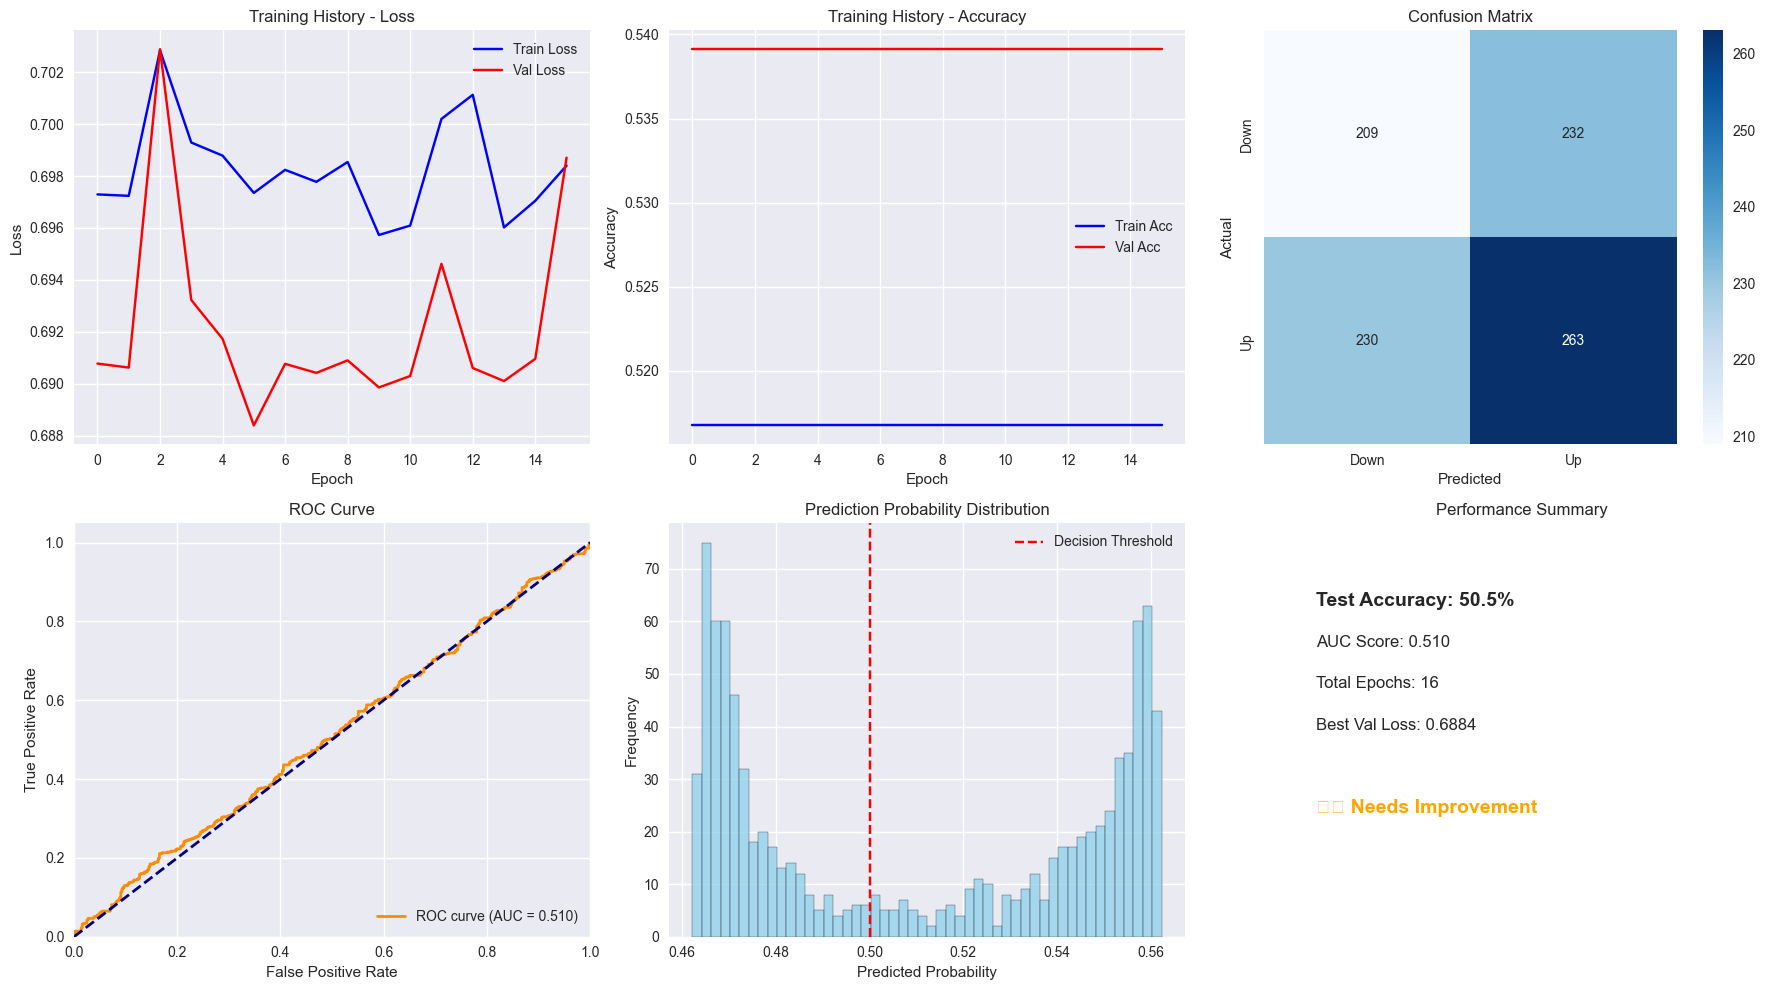

In [67]:
# =============================================================================
# 7. VISUALIZATION AND ANALYSIS
# =============================================================================

def plot_results(history, results):
    """Plot comprehensive results"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Training history - Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0, 0].plot(history['val_loss'], label='Val Loss', color='red')
    axes[0, 0].set_title('Training History - Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Training history - Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Acc', color='blue')
    axes[0, 1].plot(history['val_acc'], label='Val Acc', color='red')
    axes[0, 1].set_title('Training History - Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Confusion Matrix
    cm = confusion_matrix(results['y_true'], results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'],
                ax=axes[0, 2])
    axes[0, 2].set_title('Confusion Matrix')
    axes[0, 2].set_ylabel('Actual')
    axes[0, 2].set_xlabel('Predicted')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(results['y_true'], results['y_prob'])
    axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, 
                    label=f'ROC curve (AUC = {results["auc_score"]:.3f})')
    axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1, 0].set_xlim([0.0, 1.0])
    axes[1, 0].set_ylim([0.0, 1.05])
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve')
    axes[1, 0].legend(loc="lower right")
    axes[1, 0].grid(True)
    
    # Prediction Distribution
    axes[1, 1].hist(results['y_prob'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold')
    axes[1, 1].set_title('Prediction Probability Distribution')
    axes[1, 1].set_xlabel('Predicted Probability')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Summary Stats
    axes[1, 2].text(0.1, 0.8, f'Test Accuracy: {results["accuracy"]:.1%}', fontsize=14, weight='bold')
    axes[1, 2].text(0.1, 0.7, f'AUC Score: {results["auc_score"]:.3f}', fontsize=12)
    axes[1, 2].text(0.1, 0.6, f'Total Epochs: {len(history["train_loss"])}', fontsize=12)
    axes[1, 2].text(0.1, 0.5, f'Best Val Loss: {min(history["val_loss"]):.4f}', fontsize=12)
    
    if results['accuracy'] > 0.55:
        status = "✅ Good Performance!"
        color = 'green'
    else:
        status = "⚠️ Needs Improvement"
        color = 'orange'
    
    axes[1, 2].text(0.1, 0.3, status, fontsize=14, weight='bold', color=color)
    axes[1, 2].set_xlim(0, 1)
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].axis('off')
    axes[1, 2].set_title('Performance Summary')
    
    plt.tight_layout()
    plt.show()

# Plot results
if df is not None:
    plot_results(history, results)

In [68]:
# =============================================================================
# 8. SAVE MODEL AND FINAL SUMMARY
# =============================================================================

def save_model_and_summary(model, data, results, history):
    """Save the trained model and create summary"""
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Save model
    model_file = f"models/proven_lstm_aapl_{timestamp}.pth"
    os.makedirs('models', exist_ok=True)
    torch.save(model.state_dict(), model_file)
    
    # Save scaler
    import joblib
    scaler_file = f"models/proven_scaler_aapl_{timestamp}.pkl"
    joblib.dump(data['scaler'], scaler_file)
    
    # Create comprehensive summary
    summary = {
        'model_info': {
            'architecture': 'Proven LSTM from References',
            'input_features': len(data['feature_cols']),
            'sequence_length': data['X_train'].shape[1],
            'model_file': model_file,
            'scaler_file': scaler_file
        },
        'training_config': PROVEN_PARAMS,
        'performance': {
            'test_accuracy': float(results['accuracy']),
            'auc_score': float(results['auc_score']),
            'best_val_loss': float(min(history['val_loss'])),
            'total_epochs': len(history['train_loss'])
        },
        'data_info': {
            'total_samples': len(data['X_train']) + len(data['X_val']) + len(data['X_test']),
            'train_samples': len(data['X_train']),
            'val_samples': len(data['X_val']),
            'test_samples': len(data['X_test']),
            'feature_count': len(data['feature_cols'])
        },
        'timestamp': timestamp
    }
    
    summary_file = f"models/proven_lstm_summary_{timestamp}.json"
    with open(summary_file, 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"\\n💾 Model and results saved:")
    print(f"   Model: {model_file}")
    print(f"   Scaler: {scaler_file}")
    print(f"   Summary: {summary_file}")
    
    return summary

# Save everything
if df is not None:
    summary = save_model_and_summary(model, data, results, history)
    
    print(f"\\n🎉 PROVEN LSTM TRAINING COMPLETE!")
    print(f"{'='*60}")
    print(f"📊 Final Results:")
    print(f"   Test Accuracy: {results['accuracy']:.1%}")
    print(f"   AUC Score: {results['auc_score']:.3f}")
    print(f"   Training Samples: {len(data['X_train']):,}")
    print(f"   Model Architecture: Input({len(data['feature_cols'])}) → LSTM(100) → LSTM(50) → Dense(1)")
    
    if results['accuracy'] > 0.55:
        print(f"\\n✅ SUCCESS! The proven architecture is learning patterns!")
        print(f"   {results['accuracy']:.1%} accuracy is above random chance (50%)")
        print(f"   This is a solid baseline to build upon")
    else:
        print(f"\\n📈 BASELINE ESTABLISHED")
        print(f"   Model is training but needs optimization")
        print(f"   Consider: longer sequences, feature engineering, or hyperparameter tuning")
    
    print(f"\\n🚀 Next steps:")
    print(f"   1. Analyze feature importance")
    print(f"   2. Try different sequence lengths")
    print(f"   3. Add sentiment data integration")
    print(f"   4. Experiment with ensemble methods")
else:
    print("❌ Training failed - check data collection and processing steps")

\n💾 Model and results saved:
   Model: models/proven_lstm_aapl_20250701_202349.pth
   Scaler: models/proven_scaler_aapl_20250701_202349.pkl
   Summary: models/proven_lstm_summary_20250701_202349.json
\n🎉 PROVEN LSTM TRAINING COMPLETE!
📊 Final Results:
   Test Accuracy: 50.5%
   AUC Score: 0.510
   Training Samples: 4,356
   Model Architecture: Input(56) → LSTM(100) → LSTM(50) → Dense(1)
\n📈 BASELINE ESTABLISHED
   Model is training but needs optimization
   Consider: longer sequences, feature engineering, or hyperparameter tuning
\n🚀 Next steps:
   1. Analyze feature importance
   2. Try different sequence lengths
   3. Add sentiment data integration
   4. Experiment with ensemble methods
